# What is cavapy?

Working with CORDEX-CORE climate projections normally means downloading terabytes of raw NetCDF files, reprojecting from rotated polar coordinates to regular lat/lon, writing boilerplate to handle non-Gregorian calendars, converting units, subsetting grids, wrangling multi-model ensembles, and layering bias correction on top. All before you can run a single analysis.

`cavapy` collapses all of that into one function call.

It streams only the spatial slice you need over OPeNDAP (no local archive required) and returns analysis-ready `xarray.DataArray` objects with consistent units, a standard Gregorian calendar, and optional bias correction already applied.

It is part of the [CAVA](https://risk-team.github.io/CAVAanalytics/articles/CAVA.html) (Climate and Agriculture Risk Visualization and Assessment) ecosystem, a joint initiative of FAO, Instituto de Física de Cantabria (CSIC-University of Cantabria), the University of Cape Town, and Predictia.

In [1]:
import cavapy

## What gets handled automatically

A single `get_climate_data()` call orchestrates a full pipeline:

| Step | What happens |
| --- | --- |
| **Inventory lookup** | Resolves the correct OPeNDAP URL(s) for your GCM/RCM/RCP/domain combination from a live THREDDS inventory |
| **Spatial subsetting** | Streams only the grid cells inside your country or bounding box — no full-file downloads |
| **Country → bbox** | Converts a country name to a precise bounding box using Natural Earth shapefiles |
| **Unit conversion** | K → °C for temperature; kg m⁻² s⁻¹ → mm/day for precipitation; J/m² → W/m² for solar radiation; 10 m → 2 m for wind speed |
| **Regridding** | CORDEX outputs are natively in rotated polar coordinates; the data served here has already been regridded to a regular lat/lon grid, so standard spatial operations work out of the box |
| **Calendar harmonization** | Converts 360-day and other non-Gregorian CORDEX calendars to Gregorian, filling gaps with NaN |
| **Parallelization** | Variables are fetched in parallel processes; within each process, threaded downloads handle multi-file retrieval |
| **Fault tolerance** | OPeNDAP connections retry up to 3 times with backoff; C-level noise is suppressed on intermediate attempts |
| **Bias correction** | ERA5 is automatically fetched as the reference; EQM is trained and applied — no external tools needed |
| **Domain validation** | If your bounding box falls outside the chosen CORDEX domain, a corrected domain is suggested |

---

## Data Coverage

### Sources

- CORDEX-CORE regional climate simulations (25 km)
- ERA5 reanalysis (used directly and as the reference for bias correction)

Data is hosted on the Instituto de Física de Cantabria THREDDS infrastructure.

## Quick Start

### 1) Pre-bias-corrected projections (recommended)

Uses `CORDEX-CORE-BC`: the full CORDEX archive already corrected against ERA5 using the ISIMIP3 methodology. No further correction is applied at download time.

In [2]:
%%time

togo = cavapy.get_climate_data(
    country="Togo",
    variables=["tasmin", "pr"],
    cordex_domain="AFR-22",
    rcp="rcp26",
    gcm="MPI",
    rcm="REMO",
    years_up_to=2030,
    dataset="CORDEX-CORE-BC",
)

09:42:05 [INFO] climate.URL-validation-MPI-REMO-rcp26: https://hub.ipcc.ifca.es/thredds/dodsC/fao/interp025bc/aggregations/CORDEX/output/AFR-22/GERICS/MPI-M-MPI-ESM-LR/rcp26/r1i1p1/REMO2015/v1/day/CORDEX_output_AFR-22_GERICS_MPI-M-MPI-ESM-LR_rcp26_r1i1p1_REMO2015_v1_day.ncml
INFO:climate.URL-validation-MPI-REMO-rcp26:https://hub.ipcc.ifca.es/thredds/dodsC/fao/interp025bc/aggregations/CORDEX/output/AFR-22/GERICS/MPI-M-MPI-ESM-LR/rcp26/r1i1p1/REMO2015/v1/day/CORDEX_output_AFR-22_GERICS_MPI-M-MPI-ESM-LR_rcp26_r1i1p1_REMO2015_v1_day.ncml
09:42:12 [INFO] climate.MPI-REMO-tasmin-rcp26: Connection established
INFO:climate.MPI-REMO-tasmin-rcp26:Connection established
09:42:12 [INFO] climate.MPI-REMO-pr-rcp26: Connection established
INFO:climate.MPI-REMO-pr-rcp26:Connection established
09:42:36 [INFO] climate.MPI-REMO-pr-rcp26: CORDEX data for pr has been processed: unit conversion (mm), calendar transformation (360-day to Gregorian), time selection (2006-2030)
INFO:climate.MPI-REMO-pr-rcp26:CO

CPU times: user 175 ms, sys: 54.9 ms, total: 230 ms
Wall time: 47.2 s


## Core workflows and plotting

`cavapy` includes built-in plotting helpers that work directly on the returned DataArrays.

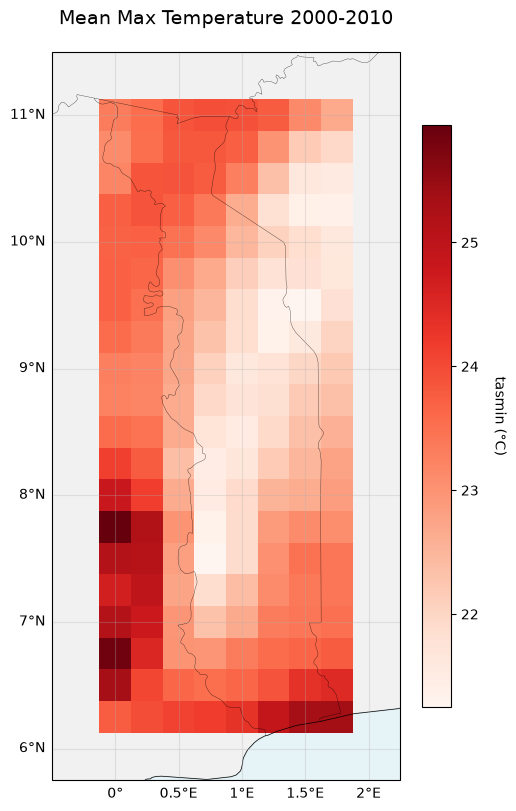

In [3]:
fig = cavapy.plot_spatial_map(
    togo["tasmin"],
    time_period=(2000, 2010),
    title="Mean Max Temperature 2000-2010",
    cmap="Reds",
)

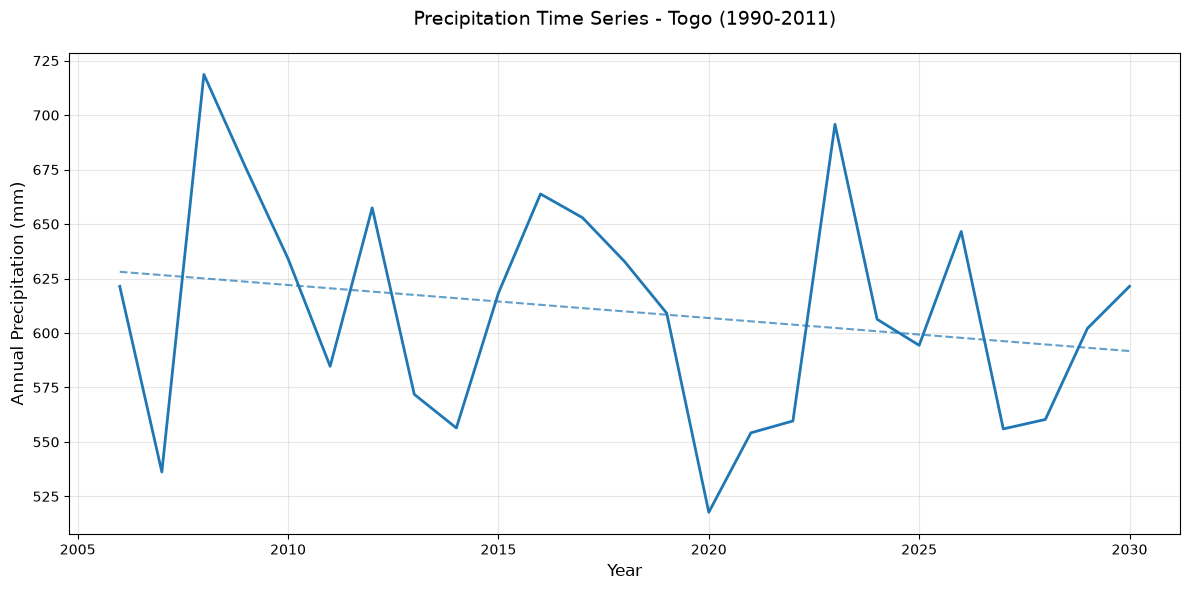

In [4]:
fig = cavapy.plot_time_series(
    togo["pr"],
    title="Precipitation Time Series - Togo (1990-2011)",
    trend_line=True,
    ylabel="Annual Precipitation (mm)",
    aggregation="sum",
    figsize=(12, 6),
)